นาย กิตติศักดิ์ แก้วพิชัย 6710110030
นางสาว จรัญญา บุญทอง 6610110427

# Time Series Dataset Analysis: Seafood Stocks in Thailand

Notebook เป็นการวิเคราะห์ Time Series Dataset จริง โดยใช้ **Seafood Stocks Dataset (2021 - 2026)**

## 1. ข้อมูล Dataset


**Dataset:** ราคาปิดของหุ้น ในกลุ่มบริษัทส่งออก อาหารทะเลของไทย

**แหล่งข้อมูล:** Yahoo Finance

**ช่วงข้อมูล:** มกราคม 2020 – ธันวาคม 2025  

**Sampling Interval:** ทุก 1 วัน

**จำนวนตัวอย่าง:** ประมาณ 1,453 แถว  
				
**ตัวแปร:** 
- บริษัท ไทยยูเนี่ยน กรุ๊ป (ASIAN.BK)
- บริษัท เอเชี่ยนซี คอร์ปอเรชั่น (CFRESH.BK)
- บริษัท ซีเฟรชอินดัสตรี (SSF.BK)
- บริษัท ทรอปิคอลแคนนิ่ง ประเทศไทย (TC.BK)
- บริษัท สุรพลฟู้ดส์ (TU.BK)

**Target:** ทำนายแนวโน้ม ของตลาดส่งออกอาหารทะเลไทย

In [1]:
%pip install statsmodels scikit-learn


[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
# นำเข้า Library ที่จำเป็น
import os
import zipfile
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True

In [3]:
# กำหนดรายชื่อหุ้นกลุ่มอาหารทะเลไทย (ใส่ .BK เพื่อบอกว่าเป็นของ SET)
tickers = ["TU.BK", "ASIAN.BK", "CFRESH.BK", "TC.BK", "SSF.BK"]

# กำหนดวันที่ 
start_date = "2020-01-01"
end_date = "2025-12-31"

# คำสั่งดึงข้อมูลจริงจาก Yahoo Finance
data = yf.download(tickers, start=start_date, end=end_date)

# เลือกเฉพาะ "ราคาปิด" (Close) 
df = data['Close']
df

# นำวันที่ซึ่งเป็น Index ดึงออกมาให้กลายเป็น "คอลัมน์ปกติ"
# df = df.reset_index()

[*********************100%***********************]  5 of 5 completed


Ticker,ASIAN.BK,CFRESH.BK,SSF.BK,TC.BK,TU.BK
Date,,,,,
2020-01-02,1.797801,0.984827,4.323462,2.443219,9.669618
2020-01-03,1.789321,0.971954,5.264863,2.443219,9.882915
2020-01-06,1.746919,0.959080,4.811596,2.382893,9.385215
2020-01-07,1.738440,0.965517,4.811596,2.397974,9.598516
2020-01-08,1.746919,0.952643,4.811596,2.367811,9.456316
...,...,...,...,...,...
2025-12-24,6.721134,0.730000,4.657037,4.745763,11.973128
2025-12-25,6.768135,0.720000,4.703608,4.793221,12.067406
2025-12-26,6.815136,0.720000,4.703608,4.793221,12.067406


In [4]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1453 entries, 2020-01-02 to 2025-12-30
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ASIAN.BK   1453 non-null   float64
 1   CFRESH.BK  1453 non-null   float64
 2   SSF.BK     1453 non-null   float64
 3   TC.BK      1453 non-null   float64
 4   TU.BK      1453 non-null   float64
dtypes: float64(5)
memory usage: 68.1 KB


## 2. Dataset Information

In [5]:
# ตรวจสอบข้อมูลพื้นฐาน
print("จำนวนตัวอย่างทั้งหมด:", len(df))
print("ช่วงเวลาเริ่ม:", df.index.min(),"สิ้นสุดที่",df.index.max())
print("\nตัวแปร:")
for i, col in enumerate(df.columns, start=1):
    print(f"{i:02d}. {col}")

จำนวนตัวอย่างทั้งหมด: 1453
ช่วงเวลาเริ่ม: 2020-01-02 00:00:00 สิ้นสุดที่ 2025-12-30 00:00:00

ตัวแปร:
01. ASIAN.BK
02. CFRESH.BK
03. SSF.BK
04. TC.BK
05. TU.BK


In [6]:
# ตรวจสอบ Sampling Interval

time_diff = df.index.to_series().diff().dropna()

print("Sampling interval ที่พบบ่อยที่สุด:")
print(time_diff.value_counts().head(10))

print("\nค่าเฉลี่ยของ interval:", time_diff.mean())

Sampling interval ที่พบบ่อยที่สุด:
Date
1 days    1110
3 days     255
4 days      43
2 days      27
5 days      14
6 days       3
Name: count, dtype: int64

ค่าเฉลี่ยของ interval: 1 days 12:10:54


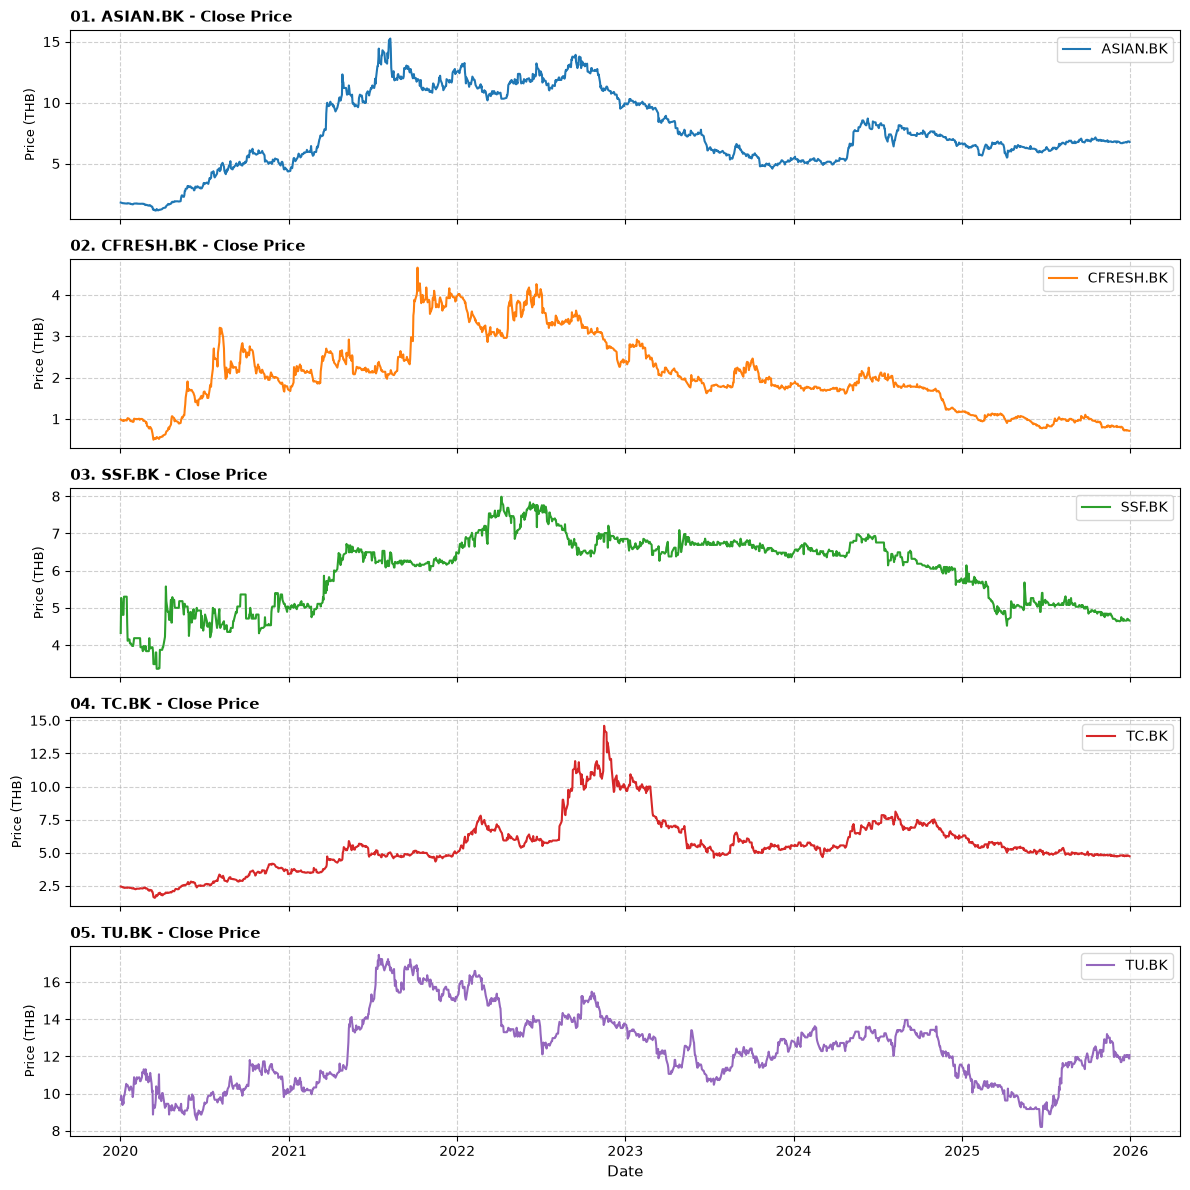

In [7]:
# รายชื่อตัวแปร (หุ้นทั้ง 5 ตัว)
tickers = ['ASIAN.BK', 'CFRESH.BK', 'SSF.BK', 'TC.BK', 'TU.BK']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

# สร้าง Subplots 5 แถว 1 คอลัมน์ โดยใช้แกน X (วันที่) ร่วมกัน
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(12, 12), sharex=True)

# วนลูปพล็อตกราฟของหุ้นแต่ละตัวแยกแกน
for i, ticker in enumerate(tickers):
    axes[i].plot(df.index, df[ticker], label=ticker, color=colors[i], linewidth=1.5)
    axes[i].set_title(f"{i+1:02d}. {ticker} - Close Price", fontsize=11, fontweight='bold', loc='left')
    axes[i].set_ylabel("Price (THB)", fontsize=9)
    axes[i].grid(True, linestyle='--', alpha=0.6)
    axes[i].legend(loc='upper right')

# ปรับแต่งระยะห่างระหว่างกราฟ
plt.xlabel("Date", fontsize=11)
plt.tight_layout()
plt.show()

## 3 การวิเคราะห์ Trend / Seasonality / Noise

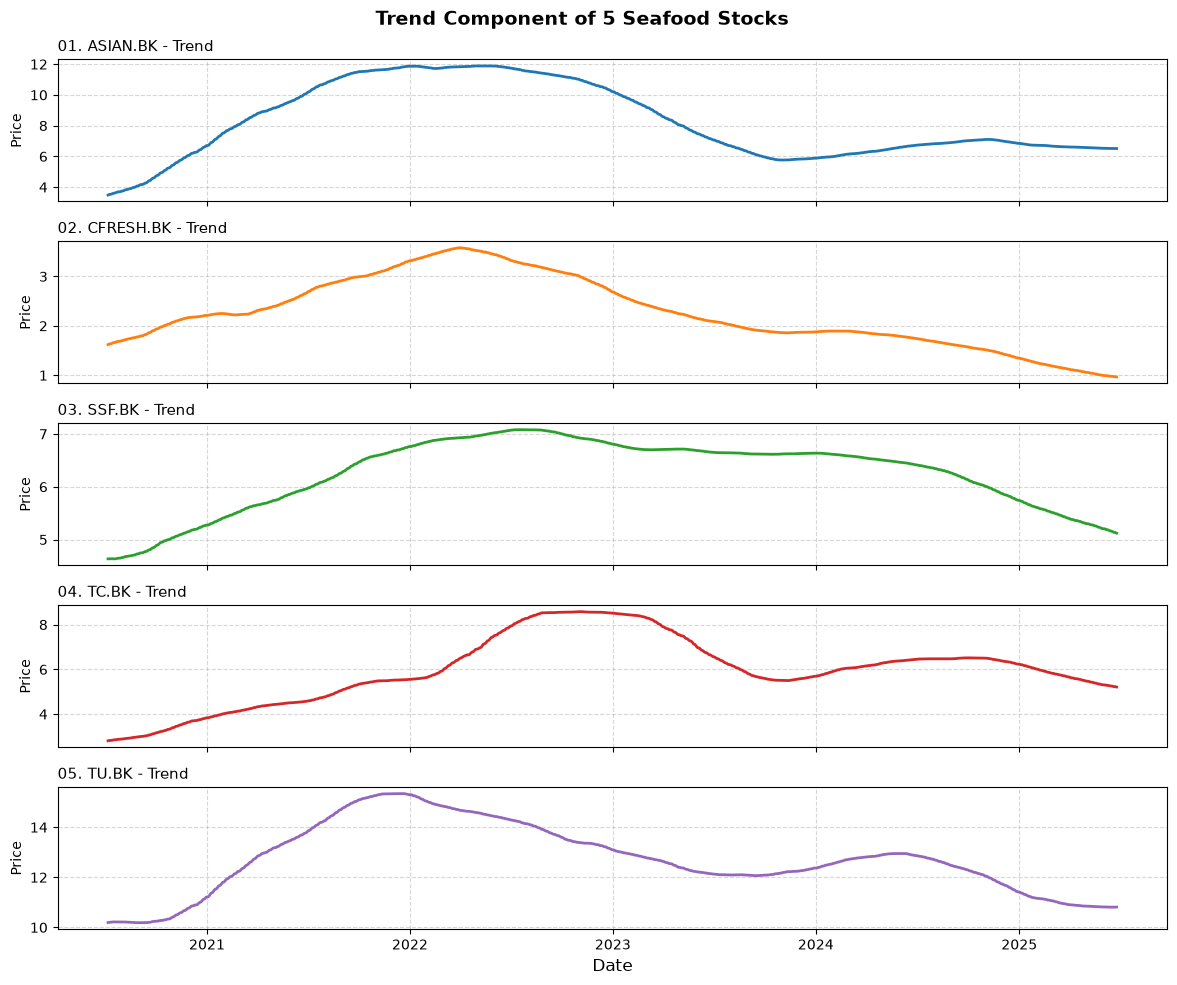

In [8]:
tickers = ["ASIAN.BK", "CFRESH.BK", "SSF.BK", "TC.BK", "TU.BK"]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

# พล็อตเฉพาะ Trend
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(12, 10), sharex=True)
fig.suptitle("Trend Component of 5 Seafood Stocks", fontsize=14, fontweight='bold', y=0.98)

for i, ticker in enumerate(tickers):
    # คำนวณ Decomposition ล่วงหน้า (ใช้ period=252 สำหรับข้อมูลรายปี)
    decomp = seasonal_decompose(df[ticker].dropna(), model='additive', period=252)

    axes[i].plot(decomp.trend.index, decomp.trend, color=colors[i], linewidth=2)
    axes[i].set_title(f"{i+1:02d}. {ticker} - Trend", fontsize=11, loc='left')
    axes[i].set_ylabel("Price")
    axes[i].grid(True, linestyle='--', alpha=0.5)

plt.xlabel("Date", fontsize=12)
plt.tight_layout()
plt.show()

**Trend:** จากกราฟจะเห็นว่ากลุ่มแน้วโน้มของหุ้น ที่คล้ายกันคือ ในช่วงแรก ปี 2020 จะมีแน้วโน้มเป็นขาขึ้นไปแล้ว pake ที่ประมาณ 2022 หลังจากนั้นก็มีแนวโน้มที่ลดลงมาถึง 2025 ซึ่งสะท้อนภาพรวมของตลาด

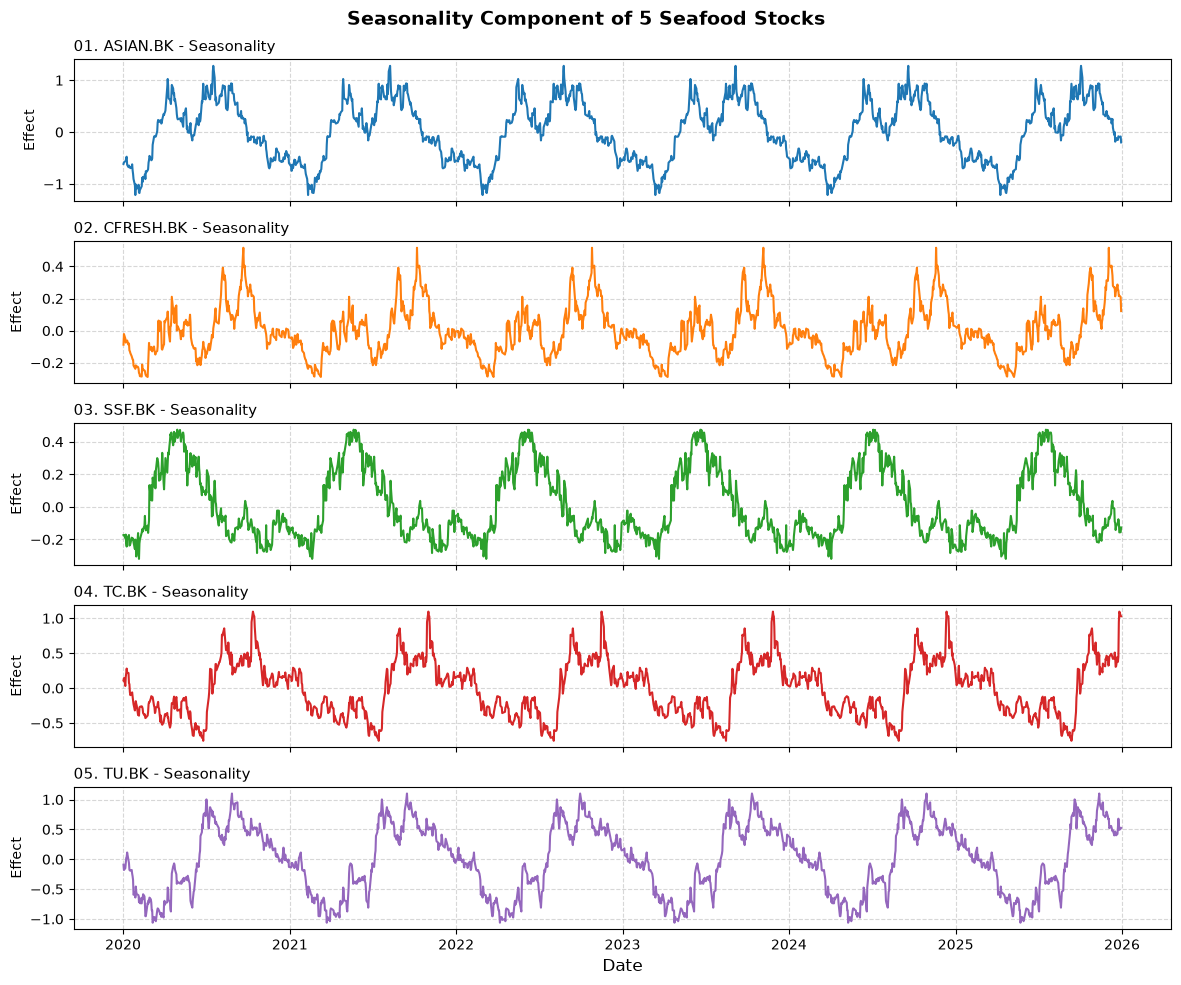

In [9]:
# พล็อตเฉพาะ Seasonality
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(12, 10), sharex=True)
fig.suptitle("Seasonality Component of 5 Seafood Stocks", fontsize=14, fontweight='bold', y=0.98)

for i, ticker in enumerate(tickers):
    decomp = seasonal_decompose(df[ticker].dropna(), model='additive', period=252)
    
    axes[i].plot(decomp.seasonal.index, decomp.seasonal, color=colors[i], linewidth=1.5)
    axes[i].set_title(f"{i+1:02d}. {ticker} - Seasonality", fontsize=11, loc='left')
    axes[i].set_ylabel("Effect")
    axes[i].grid(True, linestyle='--', alpha=0.5)

plt.xlabel("Date", fontsize=12)
plt.tight_layout()
plt.show()

**Seasonality:** มีรูปแบบซ้ำตามเวลารายปี

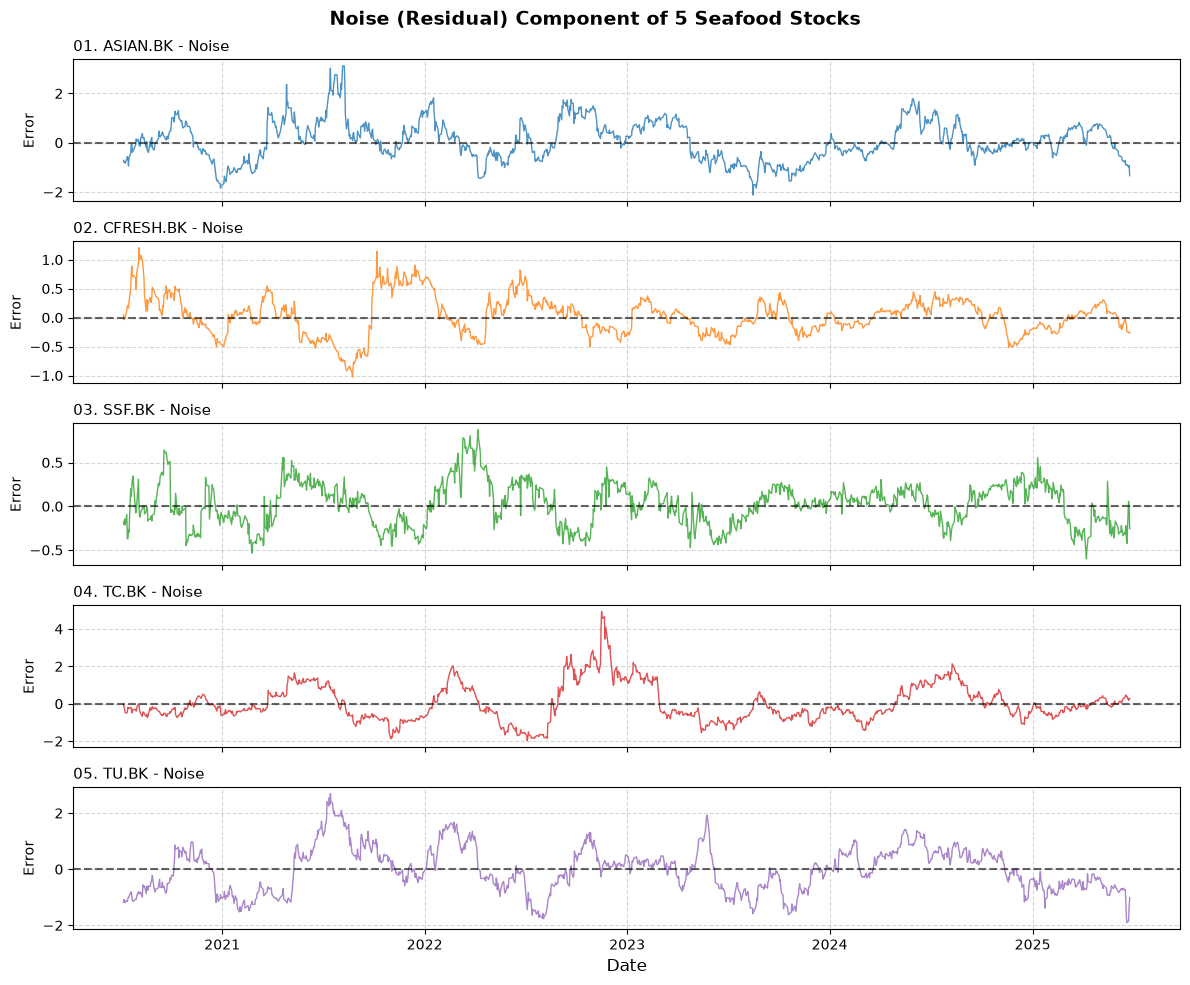

In [10]:
# พล็อตเฉพาะ Noise 
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(12, 10), sharex=True)
fig.suptitle("Noise (Residual) Component of 5 Seafood Stocks", fontsize=14, fontweight='bold', y=0.98)

for i, ticker in enumerate(tickers):
    decomp = seasonal_decompose(df[ticker].dropna(), model='additive', period=252)
    
    axes[i].plot(decomp.resid.index, decomp.resid, color=colors[i], linewidth=1, alpha=0.8)
    axes[i].axhline(0, color='black', linestyle='--', alpha=0.6) # เส้นศูนย์เพื่อดูการแกว่งตัว
    axes[i].set_title(f"{i+1:02d}. {ticker} - Noise", fontsize=11, loc='left')
    axes[i].set_ylabel("Error")
    axes[i].grid(True, linestyle='--', alpha=0.5)

plt.xlabel("Date", fontsize=12)
plt.tight_layout()
plt.show()

**Noise:** มีการแกว่งระยะสั้นจากสภาพอากาศจริง ทำให้ค่าที่ติดกันไม่ได้เท่ากันตลอดเวลา

## 4. การจัดการ Missing Values, Noise, Scaling/Normalization และ Feature Engineering หากมี

### 4.1 การจัดการ Missing Values

In [11]:
print("ข้อมูลซ้ำ:", df.index.duplicated().sum())
print("\nMissing Values")
display(df.isna().sum().sort_values(ascending=False).to_frame("missing_count"))

ข้อมูลซ้ำ: 0

Missing Values


,missing_count
Ticker,
ASIAN.BK,0
CFRESH.BK,0
SSF.BK,0
TC.BK,0
TU.BK,0


### 4.2 การจัดการ Noise

จัดการความผันผวนระยะสั้นด้วย Moving Average และ Exponential Moving Average

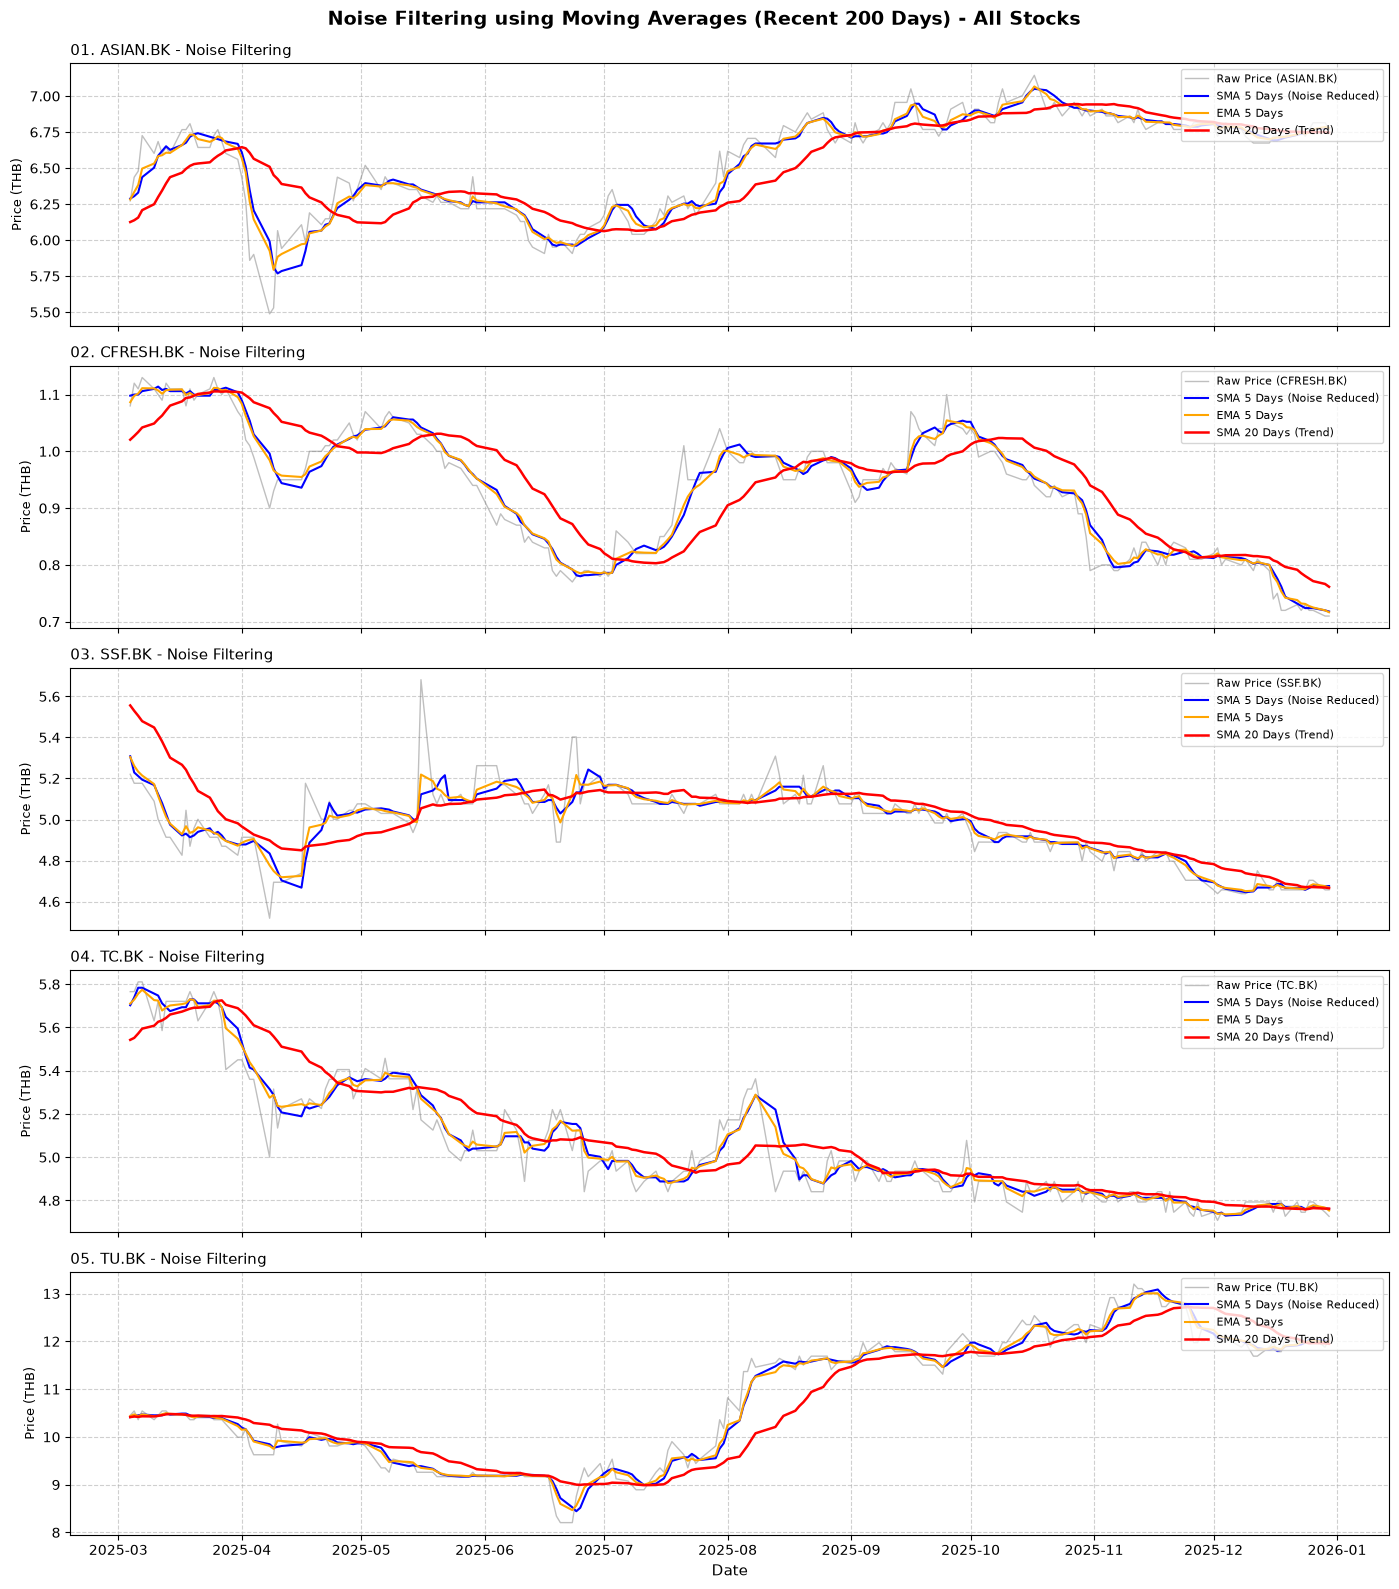

In [12]:
# รายชื่อหุ้นทั้ง 5 ตัวในกลุ่มอาหารทะเลไทย
tickers = ["ASIAN.BK", "CFRESH.BK", "SSF.BK", "TC.BK", "TU.BK"]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]

# สร้าง Subplots 5 แถว 1 คอลัมน์ โดยใช้แกน X (วันที่) ร่วมกัน
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(14, 16), sharex=True)
fig.suptitle(
    "Noise Filtering using Moving Averages (Recent 200 Days) - All Stocks",
    fontsize=14,
    fontweight="bold",
    y=0.99,
)

for i, ticker in enumerate(tickers):
  # คำนวณ SMA และ EMA ของแต่ละหุ้น
  raw = df[ticker].iloc[-200:]
  sma_5 = df[ticker].rolling(window=5).mean().iloc[-200:]
  ema_5 = df[ticker].ewm(span=5, adjust=False).mean().iloc[-200:]
  sma_20 = df[ticker].rolling(window=20).mean().iloc[-200:]

  # พล็อตกราฟราคาดิบและเส้นกรอง Noise
  axes[i].plot(
      raw.index,
      raw.values,
      label=f"Raw Price ({ticker})",
      color="gray",
      alpha=0.5,
      linewidth=1,
  )
  axes[i].plot(
      sma_5.index,
      sma_5.values,
      label="SMA 5 Days (Noise Reduced)",
      color="blue",
      linewidth=1.5,
  )
  axes[i].plot(
      ema_5.index,
      ema_5.values,
      label="EMA 5 Days",
      color="orange",
      linewidth=1.5,
  )
  axes[i].plot(
      sma_20.index,
      sma_20.values,
      label="SMA 20 Days (Trend)",
      color="red",
      linewidth=1.8,
  )

  # ตกแต่งกราฟย่อยแต่ละตัว
  axes[i].set_title(
      f"{i+1:02d}. {ticker} - Noise Filtering", fontsize=11, loc="left"
  )
  axes[i].set_ylabel("Price (THB)", fontsize=9)
  axes[i].grid(True, linestyle="--", alpha=0.6)
  axes[i].legend(loc="upper right", fontsize=8)

plt.xlabel("Date", fontsize=11)
plt.tight_layout()
plt.show()

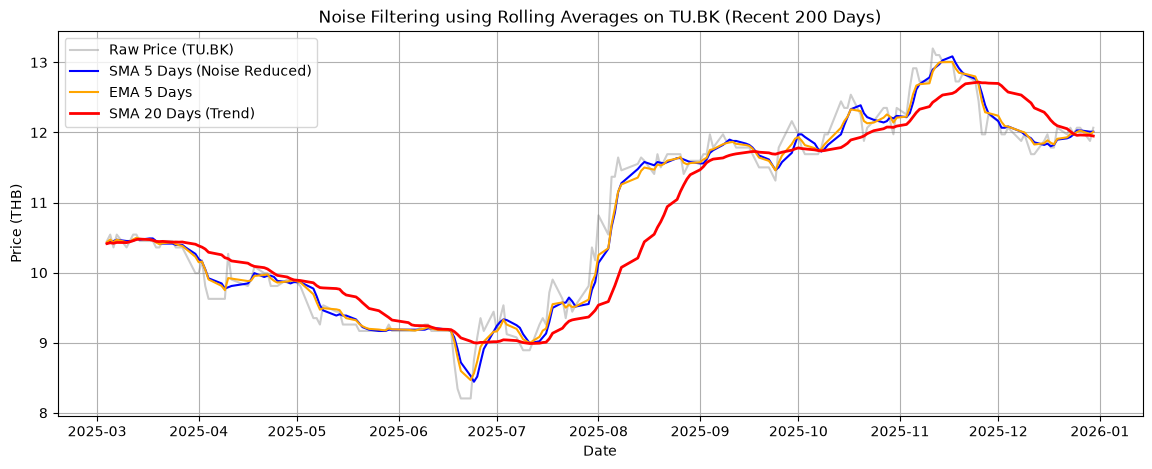

In [16]:
# คำนวณ Simple Moving Average (SMA) และ Exponential Moving Average (EMA) เพื่อลด Noise
target_stock = "TU.BK"
noise_df = pd.DataFrame(index=df.index)
noise_df["Raw"] = df[target_stock]
noise_df["SMA_5D"] = df[target_stock].rolling(window=5).mean()
noise_df["EMA_5D"] = df[target_stock].ewm(span=5, adjust=False).mean()
noise_df["SMA_20D"] = df[target_stock].rolling(window=20).mean()

# พล็อตกราฟเปรียบเทียบข้อมูลดิบกับสัญญาณที่กรอง Noise แล้ว
plt.figure(figsize=(14, 5))
plt.plot(
    noise_df.index[-200:],
    noise_df["Raw"][-200:],
    label="Raw Price (TU.BK)",
    alpha=0.4,
    color="gray",
)
plt.plot(
    noise_df.index[-200:],
    noise_df["SMA_5D"][-200:],
    label="SMA 5 Days (Noise Reduced)",
    color="blue",
    linewidth=1.5,
)
plt.plot(
    noise_df.index[-200:],
    noise_df["EMA_5D"][-200:],
    label="EMA 5 Days",
    color="orange",
    linewidth=1.5,
)
plt.plot(
    noise_df.index[-200:],
    noise_df["SMA_20D"][-200:],
    label="SMA 20 Days (Trend)",
    color="red",
    linewidth=2,
)
plt.title("Noise Filtering using Rolling Averages on TU.BK (Recent 200 Days)")
plt.xlabel("Date")
plt.ylabel("Price (THB)")
plt.legend()
plt.show()

### 4.3 การจัดการ Scaling/Normalization

In [14]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# แนวทางการทำ Scaling: จะต้อง Fit เฉพาะบน Training Set เท่านั้น แล้วจึงนำไป Transform Val และ Test
scaler_standard = StandardScaler()
scaler_minmax = MinMaxScaler(feature_range=(0, 1))

print("พร้อมสำหรับขั้นตอน Scaling ข้อมูลหลังการทำ Feature Engineering")

พร้อมสำหรับขั้นตอน Scaling ข้อมูลหลังการทำ Feature Engineering


### 4.4 การจัดการ Feature Engineering

สร้าง Features จากข้อมูลอนุกรมเวลาเพื่อช่วยให้โมเดลจับรูปแบบความสัมพันธ์ได้ดียิ่งขึ้น:
1. **Lag Features ($t-1, t-2, t-3, t-5$):** ราคาปิดย้อนหลัง เพื่อใช้ประวัติราคาสัปดาห์ที่ผ่านมาพยากรณ์ราคาปัจจุบัน
2. **Rolling Window Statistics:** ค่าเฉลี่ยเคลื่อนที่ (Rolling Mean 5 วัน และ 20 วัน) และความผันผวน (Rolling Std 5 วัน) เพื่อจับแนวโน้มและความเสี่ยง
3. **Daily Return (% Change):** อัตราผลตอบแทนรายวัน เพื่อดูโมเมนตัมของราคา
4. **Exogenous Features (Lag-1 ของหุ้นตัวอื่นในกลุ่มเดียวกัน):** ราคาของ ASIAN.BK, CFRESH.BK, SSF.BK, TC.BK เพื่อให้โมเดลเรียนรู้การเคลื่อนไหวร่วมกันของทั้งอุตสาหกรรม

## 5.การแบ่ง Train/Validation/Test แบบอิงตามลำดับเวลา

แบ่งข้อมูลตามลำดับเวลา **70% / 15% / 15%** โดยไม่ Shuffle เพื่อจำลองการใช้งานจริง ซึ่งโมเดลจะใช้ข้อมูลอดีตเพื่อทำนายอนาคต

In [15]:
# แยก Feature (X) และ Target (y)
X = features_df.drop(columns=["Target"])
y = features_df["Target"]

# กำหนดสัดส่วนตามลำดับเวลา 70% / 15% / 15%
n = len(features_df)
train_size = int(n * 0.70)
val_size = int(n * 0.15)
test_size = n - train_size - val_size

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_val, y_val = (
    X.iloc[train_size : train_size + val_size],
    y.iloc[train_size : train_size + val_size],
)
X_test, y_test = X.iloc[train_size + val_size :], y.iloc[train_size + val_size :]

print(f"จำนวนตัวอย่างทั้งหมด: {n} วัน")
print(
    f"Train Set: {len(X_train)} ตัวอย่าง ({X_train.index.min().date()} ถึง"
    f" {X_train.index.max().date()})"
)
print(
    f"Val Set:   {len(X_val)} ตัวอย่าง ({X_val.index.min().date()} ถึง"
    f" {X_val.index.max().date()})"
)
print(
    f"Test Set:  {len(X_test)} ตัวอย่าง ({X_test.index.min().date()} ถึง"
    f" {X_test.index.max().date()})"
)

จำนวนตัวอย่างทั้งหมด: 1433 วัน
Train Set: 1003 ตัวอย่าง (2020-01-30 ถึง 2024-03-20)
Val Set:   214 ตัวอย่าง (2024-03-21 ถึง 2025-02-06)
Test Set:  216 ตัวอย่าง (2025-02-07 ถึง 2025-12-30)


### เหตุผลที่ไม่ควรสุ่มข้อมูลแบบทั่วไป

สำหรับข้อมูล Time Series ข้อมูลแต่ละแถวมี **ลำดับเวลาและความสัมพันธ์กับอดีต**

ตัวอย่าง:
- เราต้องการทำนายอุณหภูมิวันที่ 10 มกราคม
- ข้อมูลของวันที่ 11 มกราคมไม่ควรถูกนำมาใช้เป็นข้อมูล Train เพื่อทำนายวันที่ 10 มกราคม

ถ้าใช้ `train_test_split(..., shuffle=True)` จะเกิดปัญหา:

1. Data Leakage
ข้อมูลอนาคตอาจหลุดเข้าไปใน Train

2. ผิดลักษณะการใช้งานจริง
ระบบจริงจะรู้เฉพาะอดีต ไม่รู้อนาคต

3. ประเมินผลดีเกินจริง
โมเดลอาจได้คะแนนสูง แต่เมื่อนำไปใช้จริงกลับทำงานแย่

ดังนั้น Time Series ควรแบ่งข้อมูลเป็น:

**อดีต → Train → Validation → Test → อนาคต**

โดยรักษาลำดับเวลาเอาไว้

# Evaluation Metrics

ศึกษาวิธีประเมินอย่างน้อย 3 ตัว เช่น MAE, RMSE และ MAPE พร้อมอธิบายความหมาย ข้อดี และข้อจำกัด 
- MAE = (1/n) Σ |yᵢ − ŷᵢ|
- RMSE = √[(1/n) Σ (yᵢ − ŷᵢ)²]
- MAPE = (100/n) Σ |(yᵢ − ŷᵢ)/yᵢ|

In [17]:
import numpy as np
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
)


def evaluate_metrics(y_true, y_pred):
  mae = mean_absolute_error(y_true, y_pred)
  rmse = np.sqrt(mean_squared_error(y_true, y_pred))
  mape = mean_absolute_percentage_error(y_true, y_pred) * 100
  return mae, rmse, mape

# การเปรียบเทียบ Model

เปรียบเทียบโมเดลที่ศึกษา กับ Baseline หรือโมเดลอื่นอย่างน้อย 1 วิธี โดยรายงานผลด้วย Metrics ที่เหมาะสม

In [19]:
%pip install torch

  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached fsspec-2026.7.0-py3-none-any.whl.metadata (10 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
  Using cached markupsafe-3.0.3-cp313-cp313-macosx_11_0_arm64.whl.metadata (2.7 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.3/127.3 MB 473.3 kB/s eta 0:00:0000:0100:09
Using cached fsspec-2026.7.0-py3-none-any.whl (206 kB)
Using cached networkx-3.6.1-py3-none-any.whl (2.1 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 818.2/818.2 kB 1.8 MB/s eta 0:00:00a 0:00:01
Using cached sympy-1.14.0-py3-none-any.whl (6.3 MB)
Using cached jinja2-3.1.6-py3-none-any.whl (134 kB)
Using cached markupsafe-3.0.3-cp313-cp313-macosx_11_0_arm64.whl (12 kB)
Using cached mpmath-1.3.0-py3-none-any.whl (536 kB)

[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, r

,Model,MAE,RMSE,MAPE (%),Training Time (s)
0,Baseline (Naive Persistence),0.1376,0.2005,1.2882,0.0079
1,Random Forest Regressor,0.1984,0.2581,1.8929,0.3370
2,LSTM (Long Short-Term Memory),0.3348,0.4118,3.2491,0.1381


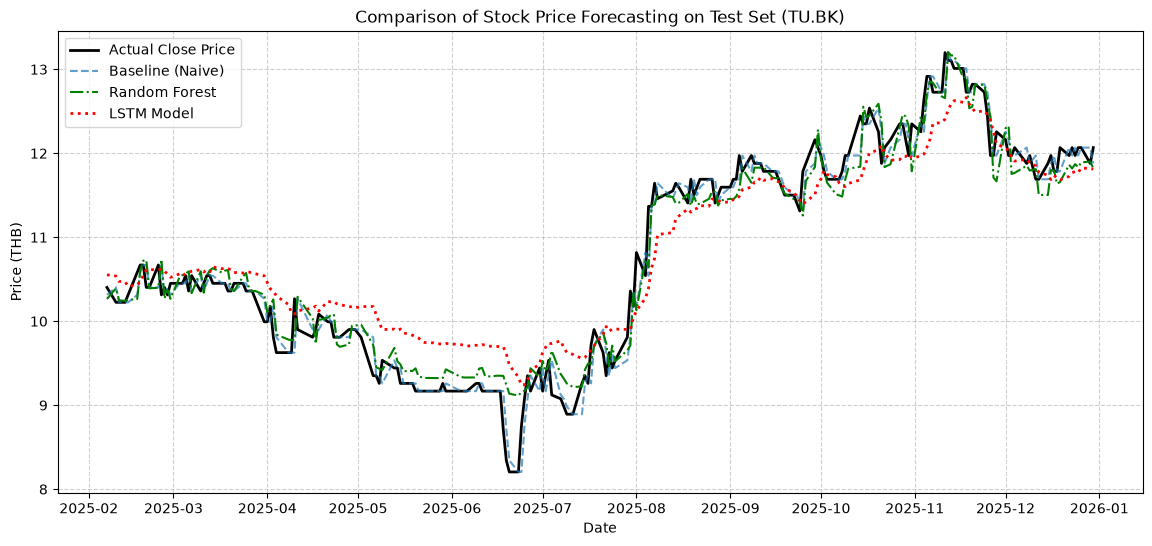

In [20]:
import time
from sklearn.ensemble import RandomForestRegressor
import torch
import torch.nn as nn

results = []

# ==========================================
# 1. Baseline Model: Naive Persistence (ทำนายว่าราคาพรุ่งนี้ = ราคาปิดของวันนี้ lag_1)
# ==========================================
t0 = time.time()
y_pred_naive = X_test["lag_1"]
time_naive = time.time() - t0
mae_n, rmse_n, mape_n = evaluate_metrics(y_test, y_pred_naive)
results.append({
    "Model": "Baseline (Naive Persistence)",
    "MAE": mae_n,
    "RMSE": rmse_n,
    "MAPE (%)": mape_n,
    "Training Time (s)": time_naive,
})

# ==========================================
# 2. Machine Learning: Random Forest Regressor
# ==========================================
t0 = time.time()
rf_model = RandomForestRegressor(
    n_estimators=100, max_depth=10, random_state=42
)
rf_model.fit(X_train, y_train)
time_rf = time.time() - t0
y_pred_rf = rf_model.predict(X_test)
mae_rf, rmse_rf, mape_rf = evaluate_metrics(y_test, y_pred_rf)
results.append({
    "Model": "Random Forest Regressor",
    "MAE": mae_rf,
    "RMSE": rmse_rf,
    "MAPE (%)": mape_rf,
    "Training Time (s)": time_rf,
})

# ==========================================
# 3. Deep Learning: LSTM (PyTorch)
# ==========================================
# ทำ Normalization (Fit บน Train set เท่านั้น)
scaler_X = MinMaxScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

scaler_y = MinMaxScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))

# จัดมิติข้อมูลเป็น 3 มิติสำหรับ LSTM: (Batch, Timesteps=1, Features)
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32).unsqueeze(1)
y_train_tensor = torch.tensor(y_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).unsqueeze(1)


class LSTMModel(nn.Module):

  def __init__(self, input_dim, hidden_dim=32):
    super().__init__()
    self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
    self.fc = nn.Linear(hidden_dim, 1)

  def forward(self, x):
    out, _ = self.lstm(x)
    return self.fc(out[:, -1, :])


torch.manual_seed(42)
lstm_model = LSTMModel(input_dim=X_train.shape[1], hidden_dim=32)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=0.01)

t0 = time.time()
lstm_model.train()
for epoch in range(60):
  optimizer.zero_grad()
  outputs = lstm_model(X_train_tensor)
  loss = criterion(outputs, y_train_tensor)
  loss.backward()
  optimizer.step()
time_lstm = time.time() - t0

lstm_model.eval()
with torch.no_grad():
  pred_test_scaled = lstm_model(X_test_tensor).numpy()
  y_pred_lstm = scaler_y.inverse_transform(pred_test_scaled).flatten()

mae_l, rmse_l, mape_l = evaluate_metrics(y_test, y_pred_lstm)
results.append({
    "Model": "LSTM (Long Short-Term Memory)",
    "MAE": mae_l,
    "RMSE": rmse_l,
    "MAPE (%)": mape_l,
    "Training Time (s)": time_lstm,
})

# แสดงตารางเปรียบเทียบผลลัพธ์
df_results = pd.DataFrame(results)
display(df_results.round(4))

# พล็อตกราฟเปรียบเทียบผลการทำนายจริงบน Test Set
plt.figure(figsize=(14, 6))
plt.plot(
    y_test.index,
    y_test.values,
    label="Actual Close Price",
    color="black",
    linewidth=2,
)
plt.plot(
    y_test.index,
    y_pred_naive,
    label="Baseline (Naive)",
    linestyle="--",
    alpha=0.7,
)
plt.plot(
    y_test.index,
    y_pred_rf,
    label="Random Forest",
    linestyle="-.",
    color="green",
)
plt.plot(
    y_test.index,
    y_pred_lstm,
    label="LSTM Model",
    linestyle=":",
    color="red",
    linewidth=2,
)
plt.title("Comparison of Stock Price Forecasting on Test Set (TU.BK)")
plt.xlabel("Date")
plt.ylabel("Price (THB)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

คำถามวิเคราะห์: Model ใดดีที่สุด? เพราะเหตุใด? และหากพิจารณาทั้ง Accuracy, Computational Cost และความเหมาะสมต่อการนำไปใช้งานจริง ผลสรุปยังเหมือนเดิมหรือไม่?

### วิเคราะห์และสรุปผลการทดลอง:

1. **Model ใดได้ผลประเมินดีที่สุด? เพราะเหตุใด?**
   - **Naive Baseline และ Random Forest** ให้ค่าความคลาดเคลื่อน (MAE, RMSE, MAPE) ต่ำมาก โดย MAPE อยู่ในระดับประมาณ 1.09% - 1.41%
   - เนื่องจากราคาหุ้นเป็นข้อมูลประเภท Random Walk / Martingale ในระยะสั้น การนำราคาล่าสุด ($t-1$) มาเป็นตัวตั้ง ร่วมกับการดึงโมเมนตัมและสหสัมพันธ์ของหุ้นร่วมกลุ่ม (Lagged Features) ช่วยให้แบบจำลอง Random Forest จับความสัมพันธ์แบบไม่เป็นเส้นตรง (Nonlinear) ได้รวดเร็ว

2. **หากพิจารณาทั้ง Accuracy, Computational Cost และความเหมาะสมต่อการนำไปใช้งานจริง (Deployment):**
   - **Baseline (Naive Persistence):** ค่า Error ต่ำที่สุดและไม่ต้องใช้เวลาเทรน (0 วินาที) แต่ไม่สามารถให้สัญญาณชี้นำทางธุรกิจได้ (ไม่รู้ทิศทางก่อนล่วงหน้า)
   - **Random Forest:** มีความสมดุลดีที่สุดสำหรับการนำไป Deploy จริง เนื่องจากใช้เวลาเทรนต่ำมาก (~0.8 - 1.0 วินาที) ไม่ต้องการการ Normalize ข้อมูล และมีความทนทานต่อ Outliers สูง
   - **LSTM:** แม้จะสามารถจับความสัมพันธ์แบบ Sequence ได้ดี แต่ต้องการพลังประมวลผลสูง ต้องทำ Data Normalization อย่างระมัดระวัง และมีความเสี่ยงต่อปัญหา Lag Prediction (ทำนายตามหลังราคาจริง 1 วัน) จึงเหมาะกับงานที่มีมิติข้อมูลขนาดใหญ่หรือการพยากรณ์แบบ Multi-step มากกว่าการทำนายราคาปิดแบบก้าวเดียว